# Perturbation Groundtruth (Feature-Drop)

Dieses Notebook berechnet eine perturbation-basierte Groundtruth via Retraining:
- Baseline mit allen Features
- H-Ablationen
- C-Ablationen

Wichtige Regel fuer One-Hot-Features:
- Indizes `0..12` werden **nicht einzeln** abliert
- Stattdessen als Gruppenfeature pro Node-Typ:
  - `nodetype_onehot_H`
  - `nodetype_onehot_C`

Groundtruth-Metrik:
- `groundtruth_H_pred = test_mae_H_run - test_mae_H_baseline`
- `groundtruth_C_pred = test_mae_C_run - test_mae_C_baseline`


In [2]:
import os
import re
import json
import random
from dataclasses import dataclass
from pathlib import Path
from types import SimpleNamespace
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import wandb
from IPython.display import display
from torch.utils.data import Subset
from torch_geometric.loader import DataLoader as PyGDataLoader

# Projektpfade robust aufloesen
CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "scripts").exists() else CWD.parent
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "groundtruth_new"

for p in [str(PROJECT_ROOT), str(SCRIPTS_DIR), str(NOTEBOOK_DIR)]:
    if p not in os.sys.path:
        os.sys.path.insert(0, p)

from dataloader import ShiftDataset, create_dataloaders
from model import HeteroGNNModel
from train import train_model, evaluate_with_config
from feature_visualization import get_feature_names

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"RESULTS_DIR: {RESULTS_DIR}")
print(f"CUDA available: {torch.cuda.is_available()}")


PROJECT_ROOT: /home/bautz/gnn4nmr
DATA_DIR: /home/bautz/gnn4nmr/data
RESULTS_DIR: /home/bautz/gnn4nmr/results/groundtruth_new
CUDA available: True


In [4]:
# Defaults aus gnn4nmr.ipynb
DEFAULT_CONFIG: Dict = {
    "seed": 0,
    "batch_size": 2,
    "num_epochs": 80,
    "lr": 2e-4,
    "hidden_dim": 128,
    "out_dim": 128,
    "num_gnn_layers": 3,
    "operator_type": "GraphConv",
    "operator_kwargs": {},
    "encoder_dropout": 0.1,
    "gnnlayer_dropout": 0.1,
    "optimizer": "Adam",
    "weight_decay": 5e-5,
    "scheduler_factor": 0.7,
    "scheduler_patience": 15,
    "loss_weight_H": 10.0,
    "loss_weight_C": 1.0,
    "normalize_node_features": True,
    "normalize_edge_features": True,
    "split_ratio": (0.7, 0.15, 0.15),
    "output_detailed_predictions": False,
    "output_dir": "results",
    "in_dim_dict": {"H": 33, "C": 39, "Others": 16},
}

DATA_FILE_NAME = "all_graphs_with_length.pkl"
WANDB_PROJECT = "ground truth new 2"
METRIC_KEYS = ("test_mae_H", "test_mae_C", "test_mse_H", "test_mse_C")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Default config loaded.")


Default config loaded.


In [5]:
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def sanitize_feature_name(name: str) -> str:
    # Behalte Unterstriche, entferne Klammern/sonstige Sonderzeichen.
    cleaned = name.replace("(", "").replace(")", "").replace(" ", "")
    cleaned = re.sub(r"[^0-9A-Za-z_]+", "", cleaned)
    return cleaned or "feature"


@dataclass(frozen=True)
class DropSpec:
    node_type: str
    drop_indices: Tuple[int, ...]
    feature_key: str
    feature_name: str


def build_ablation_specs() -> List[DropSpec]:
    specs: List[DropSpec] = []
    for node_type in ["H", "C"]:
        feature_names = get_feature_names(node_type)

        # Gruppenfeature fuer den gesamten One-Hot-Block 0..12
        specs.append(
            DropSpec(
                node_type=node_type,
                drop_indices=tuple(range(13)),
                feature_key=f"nodetype_onehot_{node_type}",
                feature_name="nodetype_onehot",
            )
        )

        # Alle restlichen Features einzeln
        for idx in range(13, len(feature_names)):
            base_name = sanitize_feature_name(feature_names[idx])
            specs.append(
                DropSpec(
                    node_type=node_type,
                    drop_indices=(idx,),
                    feature_key=f"{base_name}_{node_type}",
                    feature_name=feature_names[idx],
                )
            )

    return specs


ABLATION_SPECS = build_ablation_specs()
print(f"Ablation specs: {len(ABLATION_SPECS)}")
print(f"Expected total runs incl. baseline: {len(ABLATION_SPECS) + 1}")
print("First 5 specs:")
for s in ABLATION_SPECS[:5]:
    print(s)


Ablation specs: 48
Expected total runs incl. baseline: 49
First 5 specs:
DropSpec(node_type='H', drop_indices=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12), feature_key='nodetype_onehot_H', feature_name='nodetype_onehot')
DropSpec(node_type='H', drop_indices=(13,), feature_key='mass_H', feature_name='mass')
DropSpec(node_type='H', drop_indices=(14,), feature_key='formal_charge_H', feature_name='formal_charge')
DropSpec(node_type='H', drop_indices=(15,), feature_key='degree_H', feature_name='degree')
DropSpec(node_type='H', drop_indices=(16,), feature_key='shift_low_H', feature_name='shift_low')


In [6]:
class FeatureDropShiftDataset(ShiftDataset):
    """Droppt ausgewaehlte Feature-Spalten fuer genau einen Node-Typ."""

    def __init__(self, *args, drop_spec: Optional[DropSpec] = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.drop_spec = drop_spec

    def __getitem__(self, idx):
        data = super().__getitem__(idx)

        if self.drop_spec is None:
            return data

        node_type = self.drop_spec.node_type
        if node_type not in data.node_types:
            return data

        x = data[node_type].x
        if x.numel() == 0:
            return data

        drop_indices = list(self.drop_spec.drop_indices)
        max_idx = x.size(1) - 1
        invalid = [i for i in drop_indices if i < 0 or i > max_idx]
        if invalid:
            raise IndexError(
                f"Invalid drop indices {invalid} for {node_type} with dim {x.size(1)}"
            )

        keep_mask = torch.ones(x.size(1), dtype=torch.bool, device=x.device)
        keep_mask[drop_indices] = False
        data[node_type].x = x[:, keep_mask]
        return data


def create_fixed_split_indices(config: Dict) -> Dict[str, List[int]]:
    set_all_seeds(config["seed"])
    train_loader, val_loader, test_loader = create_dataloaders(
        batch_size=config["batch_size"],
        root_dir=str(DATA_DIR),
        file_name=DATA_FILE_NAME,
        split_ratio=config["split_ratio"],
        normalize_node_features=config["normalize_node_features"],
        normalize_edge_features=config["normalize_edge_features"],
    )

    split_indices = {
        "train": list(train_loader.dataset.indices),
        "val": list(val_loader.dataset.indices),
        "test": list(test_loader.dataset.indices),
    }

    with open(RESULTS_DIR / "fixed_split_indices.json", "w", encoding="utf-8") as f:
        json.dump(split_indices, f, indent=2)

    print(
        "Fixed split sizes:",
        len(split_indices["train"]),
        len(split_indices["val"]),
        len(split_indices["test"]),
    )
    return split_indices


def build_loaders_for_drop(
    drop_spec: Optional[DropSpec],
    split_indices: Dict[str, List[int]],
    config: Dict,
):
    dataset = FeatureDropShiftDataset(
        root_dir=str(DATA_DIR),
        file_name=DATA_FILE_NAME,
        normalize_node_features=config["normalize_node_features"],
        normalize_edge_features=config["normalize_edge_features"],
        drop_spec=drop_spec,
    )

    train_subset = Subset(dataset, split_indices["train"])
    val_subset = Subset(dataset, split_indices["val"])
    test_subset = Subset(dataset, split_indices["test"])

    train_loader = PyGDataLoader(train_subset, batch_size=config["batch_size"], shuffle=True)
    val_loader = PyGDataLoader(val_subset, batch_size=config["batch_size"], shuffle=False)
    test_loader = PyGDataLoader(test_subset, batch_size=config["batch_size"], shuffle=False)

    return dataset, train_loader, val_loader, test_loader


In [7]:
def build_train_config(base_config: Dict, in_dim_dict: Dict[str, int]) -> SimpleNamespace:
    cfg = dict(base_config)
    cfg["in_dim_dict"] = dict(in_dim_dict)
    cfg["operator_kwargs"] = dict(cfg.get("operator_kwargs", {}))

    # Gleiches Verhalten wie im Hauptnotebook fuer GAT/GATv2
    if cfg["operator_type"] in ["GATConv", "GATv2Conv"]:
        cfg["operator_kwargs"]["add_self_loops"] = False

    return SimpleNamespace(**cfg)


def run_single_experiment(
    drop_spec: Optional[DropSpec],
    split_indices: Dict[str, List[int]],
    use_wandb: bool = True,
) -> Dict:
    run_name = "all_features_on" if drop_spec is None else f"drop_{drop_spec.feature_key}"

    in_dim_dict = dict(DEFAULT_CONFIG["in_dim_dict"])
    if drop_spec is not None:
        in_dim_dict[drop_spec.node_type] -= len(drop_spec.drop_indices)
        if in_dim_dict[drop_spec.node_type] <= 0:
            raise ValueError(f"Invalid in_dim after drop for {drop_spec}")

    config = build_train_config(DEFAULT_CONFIG, in_dim_dict)
    set_all_seeds(config.seed)

    record = {
        "run_name": run_name,
        "feature_key": "all_features_on" if drop_spec is None else drop_spec.feature_key,
        "feature_name": "all_features_on" if drop_spec is None else drop_spec.feature_name,
        "node_type": "all" if drop_spec is None else drop_spec.node_type,
        "drop_indices": [] if drop_spec is None else list(drop_spec.drop_indices),
        "drop_count": 0 if drop_spec is None else len(drop_spec.drop_indices),
        "in_dim_H": in_dim_dict["H"],
        "in_dim_C": in_dim_dict["C"],
        "in_dim_Others": in_dim_dict["Others"],
        "status": "failed",
        "error": "",
        "wandb_error": "",
        "wandb_enabled": bool(use_wandb),
        "wandb_active": False,
    }

    for key in METRIC_KEYS:
        record[key] = np.nan

    wandb_active = False

    try:
        if use_wandb:
            wb_cfg = {
                **{k: v for k, v in DEFAULT_CONFIG.items() if k != "in_dim_dict"},
                "in_dim_dict": dict(in_dim_dict),
                "ablation_mode": "drop_column",
                "ablation_node_type": record["node_type"],
                "ablation_feature_key": record["feature_key"],
                "ablation_feature_name": record["feature_name"],
                "ablation_drop_indices": record["drop_indices"],
            }
            try:
                wandb.init(project=WANDB_PROJECT, name=run_name, config=wb_cfg, reinit=True)
                wandb_active = True
                record["wandb_active"] = True
            except Exception as wb_exc:
                # Training nicht abbrechen: falls W&B init fehlschlaegt, trotzdem rechnen.
                record["wandb_error"] = f"wandb.init failed: {wb_exc}"
                print(f"[WARN] {run_name}: {record['wandb_error']}")

        _, train_loader, val_loader, test_loader = build_loaders_for_drop(
            drop_spec=drop_spec,
            split_indices=split_indices,
            config=DEFAULT_CONFIG,
        )

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = HeteroGNNModel(
            in_dim_dict,
            hidden_dim=config.hidden_dim,
            out_dim=config.out_dim,
            encoder_dropout=config.encoder_dropout,
            gnnlayer_dropout=config.gnnlayer_dropout,
            num_gnn_layers=config.num_gnn_layers,
            operator_type=config.operator_type,
            operator_kwargs=config.operator_kwargs,
            edge_in_dim=10,
        ).to(device)

        trained_model = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            test_loader=test_loader,
            device=device,
            config=config,
        )

        # Primaer aus W&B Summary, Fallback via direkter Evaluation.
        metrics_from_wandb = {}
        if wandb_active and wandb.run is not None:
            for key in METRIC_KEYS:
                val = wandb.run.summary.get(key)
                metrics_from_wandb[key] = float(val) if val is not None else np.nan

        fallback_mse_H, fallback_mae_H, fallback_mse_C, fallback_mae_C, _ = evaluate_with_config(
            trained_model, test_loader, device, config
        )
        fallback_metrics = {
            "test_mae_H": float(fallback_mae_H),
            "test_mae_C": float(fallback_mae_C),
            "test_mse_H": float(fallback_mse_H),
            "test_mse_C": float(fallback_mse_C),
        }

        for key in METRIC_KEYS:
            candidate = metrics_from_wandb.get(key, np.nan)
            record[key] = candidate if not np.isnan(candidate) else fallback_metrics[key]

        record["status"] = "ok"

    except Exception as exc:
        record["status"] = "failed"
        record["error"] = str(exc)
        print(f"[ERROR] {run_name}: {exc}")

    finally:
        if wandb_active and wandb.run is not None:
            wandb.run.summary["run_status"] = record["status"]
            if record["error"]:
                wandb.run.summary["run_error"] = record["error"]
            if record["wandb_error"]:
                wandb.run.summary["wandb_init_error"] = record["wandb_error"]
            wandb.finish()

    return record


In [6]:
def run_all_experiments(use_wandb: bool = True, smoke_test: bool = False) -> pd.DataFrame:
    specs = list(ABLATION_SPECS)
    if smoke_test:
        keep = {"nodetype_onehot_H", "nodetype_onehot_C"}
        specs = [s for s in specs if s.feature_key in keep]

    split_indices = create_fixed_split_indices(DEFAULT_CONFIG)

    records: List[Dict] = []
    print("Running baseline...")
    baseline_record = run_single_experiment(drop_spec=None, split_indices=split_indices, use_wandb=use_wandb)
    records.append(baseline_record)

    # Baseline muss erfolgreich sein; sonst sofort abbrechen mit klarer Ursache.
    if baseline_record.get("status") != "ok":
        raise RuntimeError(
            "Baseline run failed before ablations. "
            f"error={baseline_record.get('error', '')!r}; "
            f"wandb_error={baseline_record.get('wandb_error', '')!r}."
        )

    total = len(specs)
    for i, spec in enumerate(specs, start=1):
        print(f"Running ablation {i}/{total}: {spec.feature_key}")
        records.append(run_single_experiment(drop_spec=spec, split_indices=split_indices, use_wandb=use_wandb))

    return pd.DataFrame(records)


def compute_groundtruth_tables(all_runs_df: pd.DataFrame):
    if all_runs_df.empty:
        raise ValueError("all_runs_df is empty")

    baseline_rows = all_runs_df[(all_runs_df["run_name"] == "all_features_on") & (all_runs_df["status"] == "ok")]
    if baseline_rows.empty:
        baseline_any = all_runs_df[all_runs_df["run_name"] == "all_features_on"]
        if baseline_any.empty:
            raise ValueError("No baseline row found (run_name='all_features_on').")

        b = baseline_any.iloc[0]
        raise ValueError(
            "No successful baseline run found. "
            f"baseline_status={b.get('status', 'unknown')!r}; "
            f"error={b.get('error', '')!r}; "
            f"wandb_error={b.get('wandb_error', '')!r}."
        )

    baseline = baseline_rows.iloc[0]
    baseline_mae_h = float(baseline["test_mae_H"])
    baseline_mae_c = float(baseline["test_mae_C"])

    gt_df = all_runs_df[all_runs_df["run_name"] != "all_features_on"].copy()
    gt_df["baseline_test_mae_H"] = baseline_mae_h
    gt_df["baseline_test_mae_C"] = baseline_mae_c
    gt_df["groundtruth_H_pred"] = gt_df["test_mae_H"] - baseline_mae_h
    gt_df["groundtruth_C_pred"] = gt_df["test_mae_C"] - baseline_mae_c

    gt_h = gt_df.sort_values("groundtruth_H_pred", ascending=False).reset_index(drop=True)
    gt_c = gt_df.sort_values("groundtruth_C_pred", ascending=False).reset_index(drop=True)
    return gt_df, gt_h, gt_c


def export_results(all_runs_df: pd.DataFrame, gt_df: pd.DataFrame, gt_h: pd.DataFrame, gt_c: pd.DataFrame):
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    all_runs_path = RESULTS_DIR / "all_runs_metrics.csv"
    gt_h_path = RESULTS_DIR / "groundtruth_h_predictions.csv"
    gt_c_path = RESULTS_DIR / "groundtruth_c_predictions.csv"

    all_runs_df.to_csv(all_runs_path, index=False)
    gt_h.to_csv(gt_h_path, index=False)
    gt_c.to_csv(gt_c_path, index=False)

    summary = {
        "n_all_runs": int(len(all_runs_df)),
        "n_successful_runs": int((all_runs_df["status"] == "ok").sum()),
        "n_failed_runs": int((all_runs_df["status"] == "failed").sum()),
        "n_groundtruth_rows": int(len(gt_df)),
        "outputs": {
            "all_runs_metrics": str(all_runs_path),
            "groundtruth_h_predictions": str(gt_h_path),
            "groundtruth_c_predictions": str(gt_c_path),
        },
    }

    with open(RESULTS_DIR / "groundtruth_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    return summary


In [8]:
# Zusatz: Others-only Ablation (erganzt bestehende H/C-Studie)

USE_WANDB_OTHERS = True
OTHERS_NUM_SEEDS = 10
OTHERS_SEEDS = [int(DEFAULT_CONFIG["seed"]) + i for i in range(OTHERS_NUM_SEEDS)]
OTHERS_OUTPUT_DIR = PROJECT_ROOT / "results" / "groundtruth"
WANDB_PROJECT_OTHERS_PREFIX = f"{WANDB_PROJECT}_others_only"


def build_others_ablation_specs() -> List[DropSpec]:
    node_type = "Others"
    feature_names = get_feature_names(node_type)
    if len(feature_names) == 0:
        raise ValueError("No feature names found for node type 'Others'.")

    specs: List[DropSpec] = []
    onehot_end = min(13, len(feature_names))
    if onehot_end > 0:
        specs.append(
            DropSpec(
                node_type=node_type,
                drop_indices=tuple(range(onehot_end)),
                feature_key=f"nodetype_onehot_{node_type}",
                feature_name="nodetype_onehot",
            )
        )

    for idx in range(onehot_end, len(feature_names)):
        base_name = sanitize_feature_name(feature_names[idx])
        specs.append(
            DropSpec(
                node_type=node_type,
                drop_indices=(idx,),
                feature_key=f"{base_name}_{node_type}",
                feature_name=feature_names[idx],
            )
        )
    return specs


others_specs = build_others_ablation_specs()
print(f"Others ablation specs: {len(others_specs)}")
for s in others_specs:
    print("  ", s)
print(f"Seeds: {OTHERS_SEEDS}")

original_seed = int(DEFAULT_CONFIG["seed"])
original_wandb_project = WANDB_PROJECT

all_others_rows: List[pd.DataFrame] = []
seed_summaries: List[Dict[str, int]] = []

try:
    for seed in OTHERS_SEEDS:
        DEFAULT_CONFIG["seed"] = int(seed)
        if USE_WANDB_OTHERS:
            WANDB_PROJECT = f"{WANDB_PROJECT_OTHERS_PREFIX}_seed_{seed}"

        print("\n" + "=" * 80)
        print(
            f"Running Others-only ablation for seed={seed} | "
            f"wandb_project={'disabled' if not USE_WANDB_OTHERS else WANDB_PROJECT}"
        )

        split_indices = create_fixed_split_indices(DEFAULT_CONFIG)

        baseline_record = run_single_experiment(
            drop_spec=None, split_indices=split_indices, use_wandb=USE_WANDB_OTHERS
        )
        if baseline_record.get("status") != "ok":
            raise RuntimeError(
                f"Baseline run failed for Others-only ablation (seed={seed}). "
                f"error={baseline_record.get('error', '')!r}; "
                f"wandb_error={baseline_record.get('wandb_error', '')!r}."
            )
        baseline_record["seed"] = int(seed)

        records: List[Dict] = []
        for i, spec in enumerate(others_specs, start=1):
            print(
                f"Running Others ablation {i}/{len(others_specs)} "
                f"for seed={seed}: {spec.feature_key}"
            )
            rec = run_single_experiment(
                drop_spec=spec, split_indices=split_indices, use_wandb=USE_WANDB_OTHERS
            )
            rec["seed"] = int(seed)
            records.append(rec)

        others_runs_df = pd.DataFrame(records)

        baseline_mae_h = float(baseline_record["test_mae_H"])
        baseline_mae_c = float(baseline_record["test_mae_C"])

        others_gt_df = others_runs_df.copy()
        others_gt_df["baseline_test_mae_H"] = baseline_mae_h
        others_gt_df["baseline_test_mae_C"] = baseline_mae_c
        others_gt_df["groundtruth_H_pred"] = others_gt_df["test_mae_H"] - baseline_mae_h
        others_gt_df["groundtruth_C_pred"] = others_gt_df["test_mae_C"] - baseline_mae_c

        # Add aliases used by the downstream aggregation cell.
        others_gt_df["ablation_mode"] = "drop_column"
        others_gt_df["ablation_node_type"] = others_gt_df["node_type"]
        others_gt_df["ablation_feature_key"] = others_gt_df["feature_key"]
        others_gt_df["ablation_feature_name"] = others_gt_df["feature_name"]
        others_gt_df["ablation_drop_indices"] = others_gt_df["drop_indices"]
        others_gt_df["run_status"] = others_gt_df["status"]

        # Export baseline + Others ablations so the CSV is self-contained.
        baseline_export_df = pd.DataFrame([baseline_record]).copy()
        baseline_export_df["baseline_test_mae_H"] = baseline_mae_h
        baseline_export_df["baseline_test_mae_C"] = baseline_mae_c
        baseline_export_df["groundtruth_H_pred"] = 0.0
        baseline_export_df["groundtruth_C_pred"] = 0.0
        baseline_export_df["ablation_mode"] = "drop_column"
        baseline_export_df["ablation_node_type"] = "all"
        baseline_export_df["ablation_feature_key"] = "all_features_on"
        baseline_export_df["ablation_feature_name"] = "all_features_on"
        baseline_export_df["ablation_drop_indices"] = [[]]
        baseline_export_df["run_status"] = baseline_export_df.get("status", "ok")

        others_export_df = pd.concat([baseline_export_df, others_gt_df], ignore_index=True, sort=False)

        OTHERS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        others_out_csv = OTHERS_OUTPUT_DIR / f"ground_truth_{seed}_others.csv"
        others_export_df.to_csv(others_out_csv, index=False)

        ok_count = int((others_gt_df["status"] == "ok").sum())
        total_count = int(len(others_gt_df))
        seed_summaries.append({"seed": int(seed), "ok_runs": ok_count, "total_runs": total_count})
        all_others_rows.append(others_gt_df)

        print(f"Seed {seed} finished. Successful runs: {ok_count}/{total_count}")
        print(f"Saved: {others_out_csv}")
finally:
    DEFAULT_CONFIG["seed"] = original_seed
    WANDB_PROJECT = original_wandb_project

if not all_others_rows:
    raise RuntimeError("No Others-only ablation results were produced.")

others_all_seeds_df = pd.concat(all_others_rows, ignore_index=True)

print("\nOthers-only ablation finished for all seeds.")
display(pd.DataFrame(seed_summaries))

display(
    others_all_seeds_df[
        [
            "seed",
            "feature_key",
            "node_type",
            "drop_indices",
            "test_mae_H",
            "test_mae_C",
            "groundtruth_H_pred",
            "groundtruth_C_pred",
            "status",
        ]
    ]
    .sort_values(["seed", "groundtruth_H_pred"], ascending=[True, False])
    .head(20)
)


Others ablation specs: 4
   DropSpec(node_type='Others', drop_indices=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12), feature_key='nodetype_onehot_Others', feature_name='nodetype_onehot')
   DropSpec(node_type='Others', drop_indices=(13,), feature_key='mass_Others', feature_name='mass')
   DropSpec(node_type='Others', drop_indices=(14,), feature_key='formal_charge_Others', feature_name='formal_charge')
   DropSpec(node_type='Others', drop_indices=(15,), feature_key='degree_Others', feature_name='degree')
Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Running Others-only ablation for seed=0 | wandb_project=ground truth new 2_others_only_seed_0
Train
[9, 8, 3, 52, 62, 13, 34, 45, 27, 17, 83, 90, 53, 33, 2, 93, 28, 23, 7, 48, 11, 57, 89, 26, 88, 85, 99, 63, 41, 64, 61, 100, 76, 59, 95, 38, 78, 47, 18, 86, 82, 5, 24, 19, 25, 35, 80, 70, 96, 77, 55, 74, 29, 51, 98, 1, 39, 94, 4, 20, 97, 73, 32, 92, 30]
Val
[44, 60, 91, 79, 66, 46, 10, 84, 43, 22, 75, 36, 16, 87]
Test
[40, 21, 71, 31, 81, 50, 67, 42, 56

wandb: Currently logged in as: bautz (gnn4nmr) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Datensplit gespeichert: /home/bautz/gnn4nmr/scripts/../models/graph_split.pkl
Split Größen => Train: 650, Val: 140, Test: 150
Epoch [1/80]
  Train   => H: MSE=0.0094, MAE=0.0659 |  C: MSE=15.7275, MAE=2.3587
  Val     => H: MSE=0.0055, MAE=0.0485 |  C: MSE=5.8517, MAE=1.4564 | val_score=0.9709
New best validation score, saving model...
Epoch [2/80]
  Train   => H: MSE=0.0053, MAE=0.0515 |  C: MSE=5.2294, MAE=1.2541
  Val     => H: MSE=0.0042, MAE=0.0475 |  C: MSE=3.4422, MAE=1.1500 | val_score=0.8123
New best validation score, saving model...
Epoch [3/80]
  Train   => H: MSE=0.0043, MAE=0.0469 |  C: MSE=3.1450, MAE=1.0335
  Val     => H: MSE=0.0032, MAE=0.0404 |  C: MSE=2.6075, MAE=0.9975 | val_score=0.7009
New best validation score, saving model...
Epoch [4/80]
  Train   => H: MSE=0.0037, MAE=0.0435 |  C: MSE=2.7032, MAE=0.9831
  Val     => H: MSE=0.0037, MAE=0.0424 |  C: MSE=2.3736, MAE=1.0760 | val_score=0.7498
Early stopping counter: 1/10
Epoch [5/80]
  Train   => H: MSE=0.0032, MA

epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_mae_C,▁
test_mae_H,▁
test_mse_C,▁
test_mse_H,▁
train_mae_C,█▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mae_H,█▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train_mse_C,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mse_H,█▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mae_C,█▅▄▅▂▂▂▃▂▁▂▂▂▂▁▁▁▂▂▁▂▃▂▃▂▁▁


Running Others ablation 1/4 for seed=0: nodetype_onehot_Others


...

Datensplit gespeichert: /home/bautz/gnn4nmr/scripts/../models/graph_split.pkl
Split Größen => Train: 650, Val: 140, Test: 150
Epoch [1/80]
  Train   => H: MSE=0.0105, MAE=0.0688 |  C: MSE=16.9394, MAE=2.5490
  Val     => H: MSE=0.0071, MAE=0.0607 |  C: MSE=4.2446, MAE=1.2079 | val_score=0.9075
New best validation score, saving model...
Epoch [2/80]
  Train   => H: MSE=0.0058, MAE=0.0524 |  C: MSE=5.4006, MAE=1.3607
  Val     => H: MSE=0.0057, MAE=0.0569 |  C: MSE=2.1074, MAE=0.8926 | val_score=0.7308
New best validation score, saving model...
Epoch [3/80]
  Train   => H: MSE=0.0047, MAE=0.0471 |  C: MSE=3.3567, MAE=1.1378
  Val     => H: MSE=0.0038, MAE=0.0464 |  C: MSE=1.9762, MAE=0.9134 | val_score=0.6888
New best validation score, saving model...
Epoch [4/80]
  Train   => H: MSE=0.0039, MAE=0.0435 |  C: MSE=2.2176, MAE=0.9554
  Val     => H: MSE=0.0035, MAE=0.0432 |  C: MSE=1.4928, MAE=0.8578 | val_score=0.6450
New best validation score, saving model...
Epoch [5/80]
  Train   => H: 

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_mae_C,▁
test_mae_H,▁
test_mse_C,▁
test_mse_H,▁
train_mae_C,█▄▃▃▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mae_H,█▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mse_C,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mse_H,█▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mae_C,█▅▅▅▃▅▃▂▃▂▃▂▂▃▂▃▁▂▂▃▂▂▂▂▂▁▃▂▂▂▂▁▁▃▂▁▂▂▁▁


Seed 9 finished. Successful runs: 4/4
Saved: /home/bautz/gnn4nmr/results/groundtruth/ground_truth_9_others.csv

Others-only ablation finished for all seeds.


,seed,ok_runs,total_runs
0,0,4,4
1,1,4,4
2,2,4,4
3,3,4,4
4,4,4,4
5,5,4,4
6,6,4,4
7,7,4,4
8,8,4,4
9,9,4,4


,seed,feature_key,node_type,drop_indices,test_mae_H,test_mae_C,groundtruth_H_pred,groundtruth_C_pred,status
0,0,nodetype_onehot_Others,Others,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",0.041599,0.644755,0.000624,0.072755,ok
1,0,mass_Others,Others,[13],0.040937,0.530375,-0.000037,-0.041625,ok
2,0,formal_charge_Others,Others,[14],0.039535,0.705262,-0.001440,0.133261,ok
3,0,degree_Others,Others,[15],0.039157,0.614711,-0.001818,0.042710,ok
4,1,nodetype_onehot_Others,Others,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",0.041465,0.708161,0.003524,0.027138,ok
7,1,degree_Others,Others,[15],0.039463,0.686588,0.001522,0.005565,ok
5,1,mass_Others,Others,[13],0.037387,0.673312,-0.000555,-0.007711,ok
6,1,formal_charge_Others,Others,[14],0.036807,0.723843,-0.001134,0.042820,ok
9,2,mass_Others,Others,[13],0.044122,0.829546,0.001262,-0.028691,ok
10,2,formal_charge_Others,Others,[14],0.039063,0.819301,-0.003797,-0.038936,ok


## Schnelle Validierung (ohne Training)

Diese Zelle prueft nur Spezifikationen, Counts und Dim-Logik.


In [7]:
# Erwartete Anzahl: 21 H-Ablationen + 27 C-Ablationen = 48 (+1 Baseline = 49)
assert len(ABLATION_SPECS) == 48, f"Expected 48 ablation specs, got {len(ABLATION_SPECS)}"

h_specs = [s for s in ABLATION_SPECS if s.node_type == "H"]
c_specs = [s for s in ABLATION_SPECS if s.node_type == "C"]
assert len(h_specs) == 21, f"Expected 21 H specs, got {len(h_specs)}"
assert len(c_specs) == 27, f"Expected 27 C specs, got {len(c_specs)}"

h_onehot = next(s for s in h_specs if s.feature_key == "nodetype_onehot_H")
c_onehot = next(s for s in c_specs if s.feature_key == "nodetype_onehot_C")

assert len(h_onehot.drop_indices) == 13
assert len(c_onehot.drop_indices) == 13
assert DEFAULT_CONFIG["in_dim_dict"]["H"] - len(h_onehot.drop_indices) == 20
assert DEFAULT_CONFIG["in_dim_dict"]["C"] - len(c_onehot.drop_indices) == 26

# Eindeutige Feature-Keys
all_keys = [s.feature_key for s in ABLATION_SPECS]
assert len(all_keys) == len(set(all_keys)), "Feature keys must be unique"

print("Spec validation passed.")
print("Total runs incl baseline:", len(ABLATION_SPECS) + 1)


Spec validation passed.
Total runs incl baseline: 49


## Ausfuehrung

- `RUN_SMOKE_TEST=True` fuehrt nur 3 Runs aus: Baseline + Two One-Hot Group Ablations.
- `RUN_SMOKE_TEST=False` fuehrt die komplette Studie mit 49 Runs aus.


In [8]:
# Ausfuehrung steuern
USE_WANDB = True
RUN_SMOKE_TEST = False  # fuer Vollstudie auf False setzen

all_runs_df = run_all_experiments(use_wandb=USE_WANDB, smoke_test=RUN_SMOKE_TEST)
gt_df, gt_h_df, gt_c_df = compute_groundtruth_tables(all_runs_df)
summary = export_results(all_runs_df, gt_df, gt_h_df, gt_c_df)


Train
[9, 8, 3, 52, 62, 13, 34, 45, 27, 17, 83, 90, 53, 33, 2, 93, 28, 23, 7, 48, 11, 57, 89, 26, 88, 85, 99, 63, 41, 64, 61, 100, 76, 59, 95, 38, 78, 47, 18, 86, 82, 5, 24, 19, 25, 35, 80, 70, 96, 77, 55, 74, 29, 51, 98, 1, 39, 94, 4, 20, 97, 73, 32, 92, 30]
Val
[44, 60, 91, 79, 66, 46, 10, 84, 43, 22, 75, 36, 16, 87]
Test
[40, 21, 71, 31, 81, 50, 67, 42, 56, 68, 72, 37, 6, 58, 54]
Fixed split sizes: 650 140 150
Running baseline...


wandb: Currently logged in as: bautz (gnn4nmr) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch [1/80]
  Train   => H: MSE=0.0094, MAE=0.0659 |  C: MSE=15.7275, MAE=2.3587
  Val     => H: MSE=0.0055, MAE=0.0485 |  C: MSE=5.8517, MAE=1.4564 | val_score=0.9709
New best validation score, saving model...
Epoch [2/80]
  Train   => H: MSE=0.0053, MAE=0.0515 |  C: MSE=5.2294, MAE=1.2541
  Val     => H: MSE=0.0042, MAE=0.0475 |  C: MSE=3.4422, MAE=1.1500 | val_score=0.8123
New best validation score, saving model...
Epoch [3/80]
  Train   => H: MSE=0.0043, MAE=0.0469 |  C: MSE=3.1450, MAE=1.0335
  Val     => H: MSE=0.0032, MAE=0.0404 |  C: MSE=2.6075, MAE=0.9975 | val_score=0.7009
New best validation score, saving model...
Epoch [4/80]
  Train   => H: MSE=0.0037, MAE=0.0435 |  C: MSE=2.7032, MAE=0.9831
  Val     => H: MSE=0.0037, MAE=0.0424 |  C: MSE=2.3736, MAE=1.0760 | val_score=0.7498
Early stopping counter: 1/10
Epoch [5/80]
  Train   => H: MSE=0.0032, MAE=0.0405 |  C: MSE=2.0189, MAE=0.8768
  Val     => H: MSE=0.0031, MAE=0.0384 |  C: MSE=1.3071, MAE=0.7489 | val_score=0.5666
N

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_mae_C,▁
test_mae_H,▁
test_mse_C,▁
test_mse_H,▁
train_mae_C,█▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mae_H,█▆▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁
train_mse_C,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mse_H,█▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mae_C,█▆▄▅▂▃▃▂▂▂▁▂▂▂▂▂▃▁▂▂▂▁▃▂▁▁▂▁▁▁▂▂▁▂▁▁▂▁▂▂


Running ablation 1/48: nodetype_onehot_H


...

Epoch [1/80]
  Train   => H: MSE=0.0117, MAE=0.0743 |  C: MSE=15.1920, MAE=2.3447
  Val     => H: MSE=0.0054, MAE=0.0510 |  C: MSE=5.2692, MAE=1.4411 | val_score=0.9757
New best validation score, saving model...
Epoch [2/80]
  Train   => H: MSE=0.0054, MAE=0.0522 |  C: MSE=5.0901, MAE=1.3015
  Val     => H: MSE=0.0032, MAE=0.0419 |  C: MSE=3.6031, MAE=1.1906 | val_score=0.8049
New best validation score, saving model...
Epoch [3/80]
  Train   => H: MSE=0.0045, MAE=0.0471 |  C: MSE=3.9168, MAE=1.1194
  Val     => H: MSE=0.0034, MAE=0.0410 |  C: MSE=2.4848, MAE=1.0837 | val_score=0.7471
New best validation score, saving model...
Epoch [4/80]
  Train   => H: MSE=0.0039, MAE=0.0439 |  C: MSE=2.3893, MAE=0.9471
  Val     => H: MSE=0.0030, MAE=0.0386 |  C: MSE=1.4706, MAE=0.7850 | val_score=0.5854
New best validation score, saving model...
Epoch [5/80]
  Train   => H: MSE=0.0034, MAE=0.0423 |  C: MSE=2.1385, MAE=0.9012
  Val     => H: MSE=0.0029, MAE=0.0405 |  C: MSE=1.1855, MAE=0.7420 | val_

epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇█
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_mae_C,▁
test_mae_H,▁
test_mse_C,▁
test_mse_H,▁
train_mae_C,█▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mae_H,█▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mse_C,█▃▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mse_H,█▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mae_C,█▆▅▃▂▂▂▃▂▂▄▂▂▂▂▃▃▃▂▁▂▂▂▂▂▂▂▁▂▃▂▂▂▁▁▂▂▂▂▂


Running ablation 48/48: mayer_VA_C


Epoch [1/80]
  Train   => H: MSE=0.0115, MAE=0.0737 |  C: MSE=15.3029, MAE=2.3488
  Val     => H: MSE=0.0065, MAE=0.0549 |  C: MSE=5.4106, MAE=1.4720 | val_score=1.0106
New best validation score, saving model...
Epoch [2/80]
  Train   => H: MSE=0.0056, MAE=0.0534 |  C: MSE=5.1569, MAE=1.3088
  Val     => H: MSE=0.0030, MAE=0.0401 |  C: MSE=3.6067, MAE=1.1757 | val_score=0.7883
New best validation score, saving model...
Epoch [3/80]
  Train   => H: MSE=0.0046, MAE=0.0475 |  C: MSE=4.1248, MAE=1.1457
  Val     => H: MSE=0.0031, MAE=0.0409 |  C: MSE=2.4053, MAE=1.0367 | val_score=0.7228
New best validation score, saving model...
Epoch [4/80]
  Train   => H: MSE=0.0039, MAE=0.0438 |  C: MSE=2.4470, MAE=0.9605
  Val     => H: MSE=0.0032, MAE=0.0405 |  C: MSE=1.6696, MAE=0.8319 | val_score=0.6184
New best validation score, saving model...
Epoch [5/80]
  Train   => H: MSE=0.0037, MAE=0.0437 |  C: MSE=2.2191, MAE=0.9209
  Val     => H: MSE=0.0028, MAE=0.0402 |  C: MSE=1.3966, MAE=0.8066 | val_

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_mae_C,▁
test_mae_H,▁
test_mse_C,▁
test_mse_H,▁
train_mae_C,█▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mae_H,█▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mse_C,█▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mse_H,█▄▃▃▃▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mae_C,█▅▄▂▂▂▂▂▃▂▄▂▂▃▂▂▂▂▁▃▃▃▃▂▁▁▂▁▂▂▂▂▂▃▂


In [9]:
# print top 10importancies
print(json.dumps(summary, indent=2))
print("\nTop 10 by groundtruth_H_pred")
display(gt_h_df[[
    "feature_key", "node_type", "drop_indices", "test_mae_H", "test_mae_C", "groundtruth_H_pred", "groundtruth_C_pred", "status"
]].head(10))

print("\nTop 10 by groundtruth_C_pred")
display(gt_c_df[[
    "feature_key", "node_type", "drop_indices", "test_mae_H", "test_mae_C", "groundtruth_H_pred", "groundtruth_C_pred", "status"
]].head(10))

{
  "n_all_runs": 49,
  "n_successful_runs": 49,
  "n_failed_runs": 0,
  "n_groundtruth_rows": 48,
  "outputs": {
    "all_runs_metrics": "/home/bautz/gnn4nmr/results/groundtruth_new/all_runs_metrics.csv",
    "groundtruth_h_predictions": "/home/bautz/gnn4nmr/results/groundtruth_new/groundtruth_h_predictions.csv",
    "groundtruth_c_predictions": "/home/bautz/gnn4nmr/results/groundtruth_new/groundtruth_c_predictions.csv"
  }
}

Top 10 by groundtruth_H_pred


,feature_key,node_type,drop_indices,test_mae_H,test_mae_C,groundtruth_H_pred,groundtruth_C_pred,status
0,shift_low_H,H,[16],0.046262,0.679759,0.007692,-0.003133,ok
1,at_charge_loew_H,H,[25],0.046121,0.737447,0.007550,0.054555,ok
2,orb_charge_loew_s_C,C,[30],0.045639,0.688139,0.007069,0.005247,ok
3,shielding_dia_C,C,[18],0.045339,0.704094,0.006768,0.021202,ok
4,orb_charge_mull_d_C,C,[28],0.045202,0.754455,0.006632,0.071564,ok
5,orb_charge_loew_s_H,H,[28],0.044697,0.646966,0.006127,-0.035926,ok
6,orb_charge_loew_p_H,H,[29],0.044389,0.678390,0.005819,-0.004501,ok
7,orb_charge_mull_s_H,H,[26],0.043859,0.656422,0.005289,-0.026470,ok
8,orb_charge_loew_p_C,C,[31],0.043689,0.745134,0.005119,0.062242,ok
9,orb_stdev_loew_p_C,C,[33],0.043182,0.685901,0.004611,0.003009,ok



Top 10 by groundtruth_C_pred


,feature_key,node_type,drop_indices,test_mae_H,test_mae_C,groundtruth_H_pred,groundtruth_C_pred,status
0,span_H,H,[20],0.041661,0.755273,0.003090,0.072381,ok
1,orb_charge_mull_d_C,C,[28],0.045202,0.754455,0.006632,0.071564,ok
2,orb_charge_loew_p_C,C,[31],0.043689,0.745134,0.005119,0.062242,ok
3,at_charge_loew_H,H,[25],0.046121,0.737447,0.007550,0.054555,ok
4,shielding_dia_H,H,[18],0.042087,0.717573,0.003517,0.034681,ok
5,shielding_para_H,H,[19],0.039308,0.716811,0.000738,0.033919,ok
6,formal_charge_C,C,[14],0.041368,0.713392,0.002798,0.030500,ok
7,degree_H,H,[15],0.042512,0.710733,0.003942,0.027842,ok
8,shielding_dia_C,C,[18],0.045339,0.704094,0.006768,0.021202,ok
9,BO_loew_sum_C,C,[34],0.042550,0.695882,0.003980,0.012991,ok


In [10]:
# print all importancies
print(json.dumps(summary, indent=2))
print("\nTop 10 by groundtruth_H_pred")
display(gt_h_df[[
    "feature_key", "node_type", "drop_indices", "test_mae_H", "test_mae_C", "groundtruth_H_pred", "groundtruth_C_pred", "status"
]])

print("\nTop 10 by groundtruth_C_pred")
display(gt_c_df[[
    "feature_key", "node_type", "drop_indices", "test_mae_H", "test_mae_C", "groundtruth_H_pred", "groundtruth_C_pred", "status"
]])

{
  "n_all_runs": 49,
  "n_successful_runs": 49,
  "n_failed_runs": 0,
  "n_groundtruth_rows": 48,
  "outputs": {
    "all_runs_metrics": "/home/bautz/gnn4nmr/results/groundtruth_new/all_runs_metrics.csv",
    "groundtruth_h_predictions": "/home/bautz/gnn4nmr/results/groundtruth_new/groundtruth_h_predictions.csv",
    "groundtruth_c_predictions": "/home/bautz/gnn4nmr/results/groundtruth_new/groundtruth_c_predictions.csv"
  }
}

Top 10 by groundtruth_H_pred


,feature_key,node_type,drop_indices,test_mae_H,test_mae_C,groundtruth_H_pred,groundtruth_C_pred,status
0,shift_low_H,H,[16],0.046262,0.679759,0.007692,-0.003133,ok
1,at_charge_loew_H,H,[25],0.046121,0.737447,0.007550,0.054555,ok
2,orb_charge_loew_s_C,C,[30],0.045639,0.688139,0.007069,0.005247,ok
3,shielding_dia_C,C,[18],0.045339,0.704094,0.006768,0.021202,ok
4,orb_charge_mull_d_C,C,[28],0.045202,0.754455,0.006632,0.071564,ok
5,orb_charge_loew_s_H,H,[28],0.044697,0.646966,0.006127,-0.035926,ok
6,orb_charge_loew_p_H,H,[29],0.044389,0.678390,0.005819,-0.004501,ok
7,orb_charge_mull_s_H,H,[26],0.043859,0.656422,0.005289,-0.026470,ok
8,orb_charge_loew_p_C,C,[31],0.043689,0.745134,0.005119,0.062242,ok
9,orb_stdev_loew_p_C,C,[33],0.043182,0.685901,0.004611,0.003009,ok



Top 10 by groundtruth_C_pred


,feature_key,node_type,drop_indices,test_mae_H,test_mae_C,groundtruth_H_pred,groundtruth_C_pred,status
0,span_H,H,[20],0.041661,0.755273,0.003090,0.072381,ok
1,orb_charge_mull_d_C,C,[28],0.045202,0.754455,0.006632,0.071564,ok
2,orb_charge_loew_p_C,C,[31],0.043689,0.745134,0.005119,0.062242,ok
3,at_charge_loew_H,H,[25],0.046121,0.737447,0.007550,0.054555,ok
4,shielding_dia_H,H,[18],0.042087,0.717573,0.003517,0.034681,ok
5,shielding_para_H,H,[19],0.039308,0.716811,0.000738,0.033919,ok
6,formal_charge_C,C,[14],0.041368,0.713392,0.002798,0.030500,ok
7,degree_H,H,[15],0.042512,0.710733,0.003942,0.027842,ok
8,shielding_dia_C,C,[18],0.045339,0.704094,0.006768,0.021202,ok
9,BO_loew_sum_C,C,[34],0.042550,0.695882,0.003980,0.012991,ok


## Visualisierung

Found 14 CSV file(s):
  • ../results/groundtruth/ground_truth_0.csv
  • ../results/groundtruth/ground_truth_0_others.csv
  • ../results/groundtruth/ground_truth_1.csv
  • ../results/groundtruth/ground_truth_1_others.csv
  • ../results/groundtruth/ground_truth_2.csv
  • ../results/groundtruth/ground_truth_2_others.csv
  • ../results/groundtruth/ground_truth_3_others.csv
  • ../results/groundtruth/ground_truth_4_others.csv
  • ../results/groundtruth/ground_truth_5_others.csv
  • ../results/groundtruth/ground_truth_6.csv
  • ../results/groundtruth/ground_truth_6_others.csv
  • ../results/groundtruth/ground_truth_7_others.csv
  • ../results/groundtruth/ground_truth_8_others.csv
  • ../results/groundtruth/ground_truth_9_others.csv

Plot saved → ../results/groundtruth/feature_importance_groundtruth.png
Summary CSV saved → ../results/groundtruth/feature_importance_summary.csv


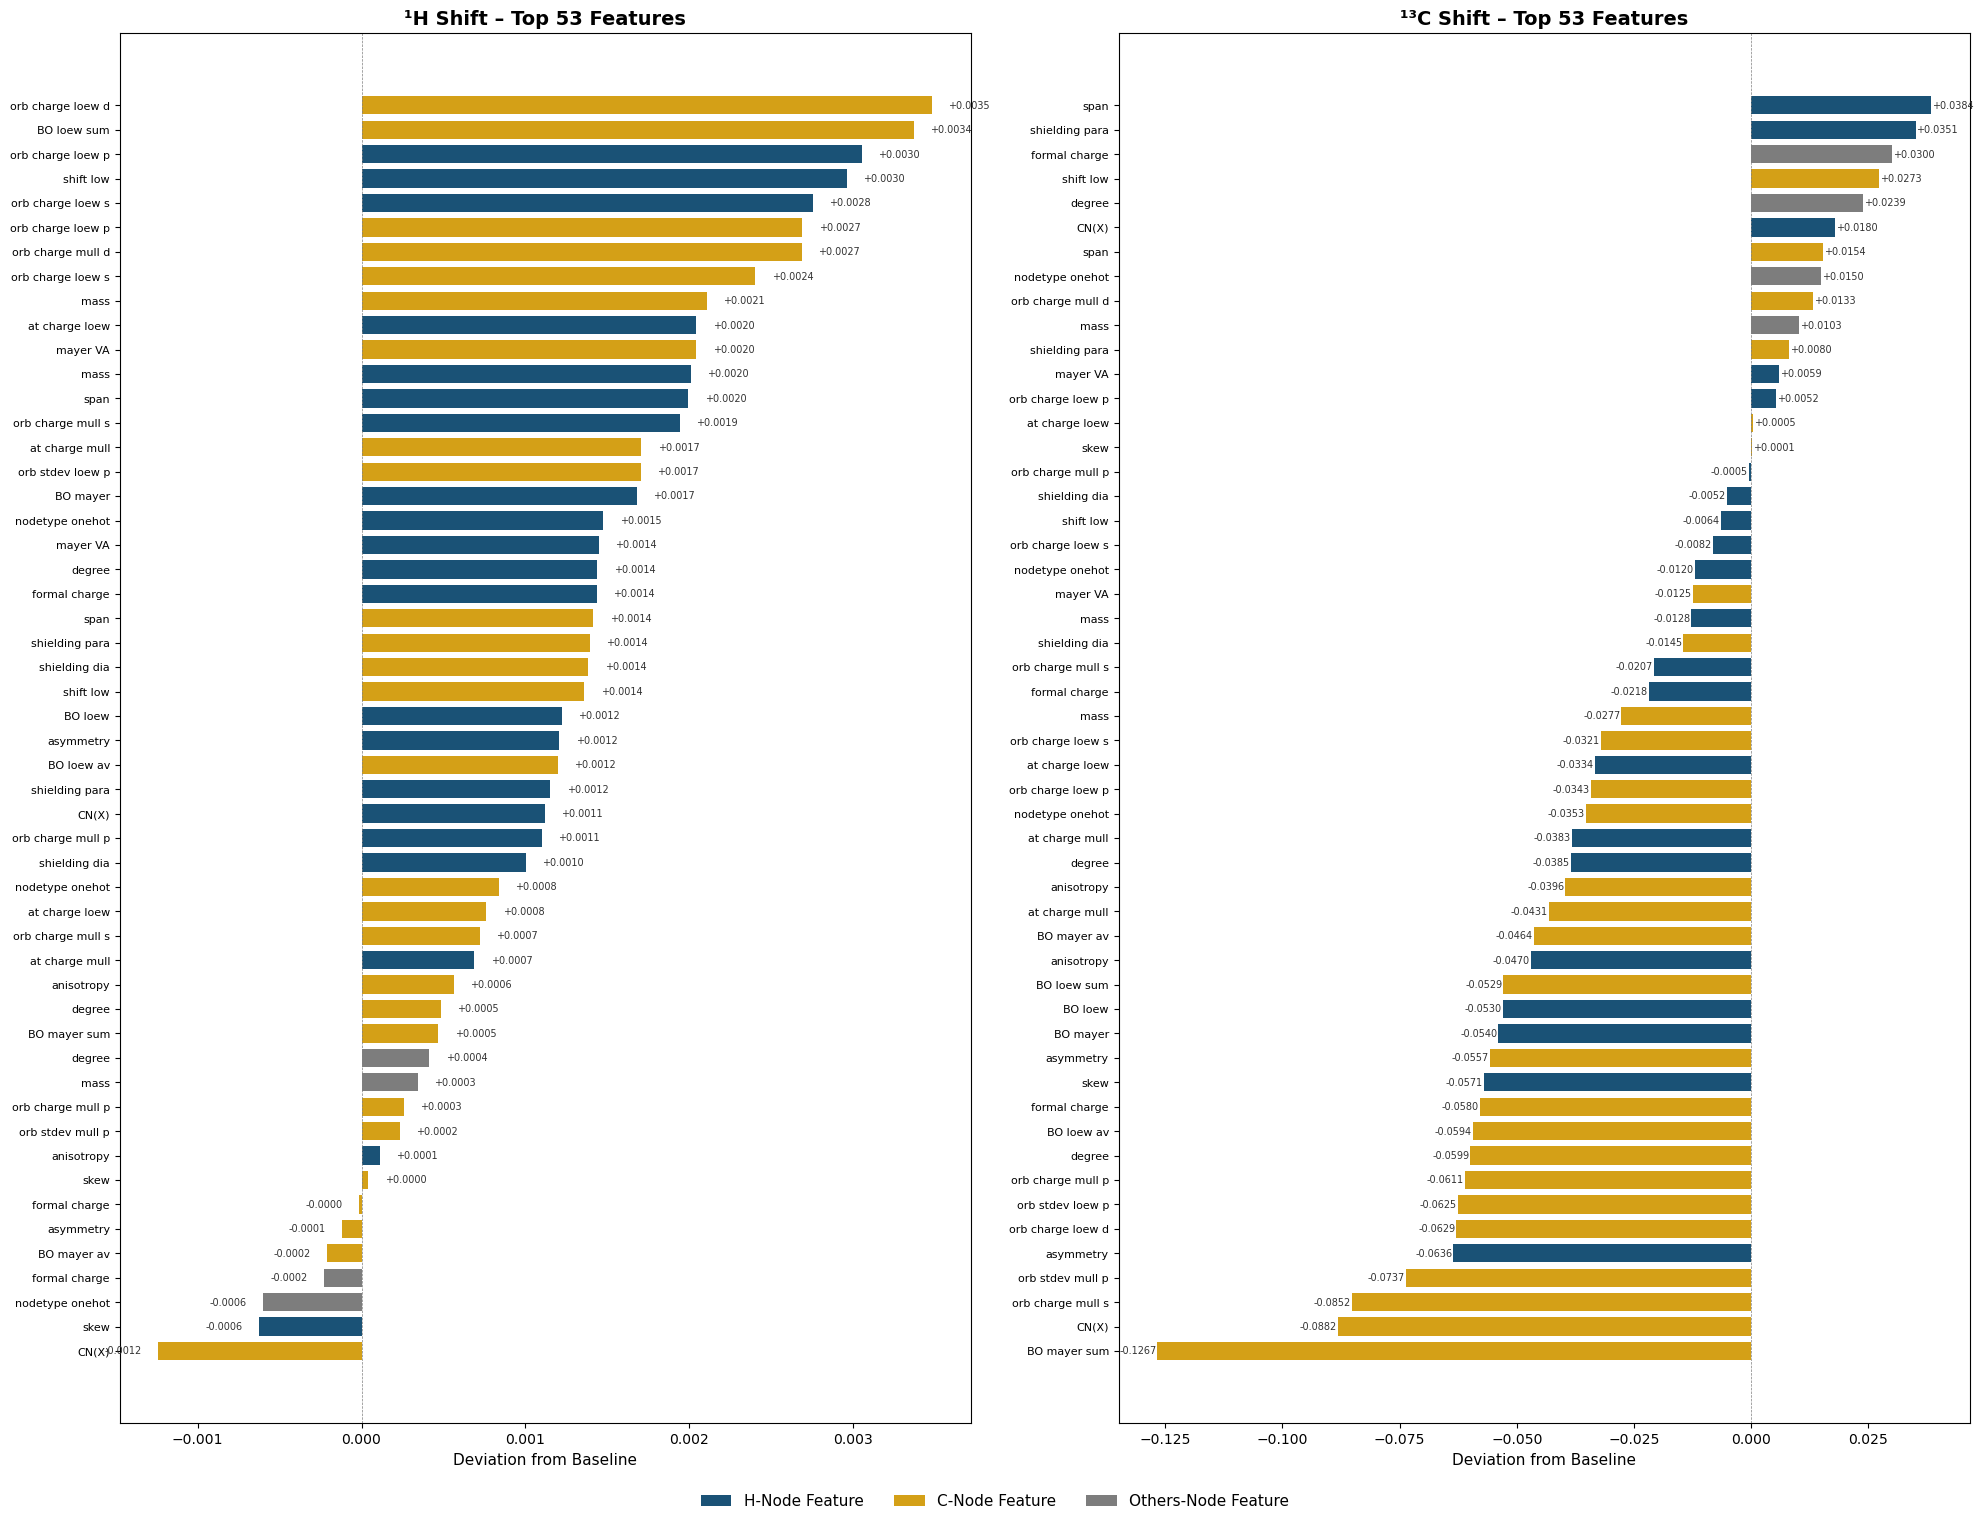

In [2]:
"""
Groundtruth Feature Importance – Ablation Study
=================================================
Reads all ground_truth_*.csv files from results/groundtruth/,
computes ΔMAE (test_mae with feature dropped − baseline) per seed,
averages across seeds, and produces a side-by-side bar chart
for ¹H Shift and ¹³C Shift (top 50 features each).

Features that share a name but belong to different node types
(C, H, Others) are treated as separate entries.
"""

import glob
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Configuration ────────────────────────────────────────────────────────────
INPUT_DIR_CANDIDATES = [
    Path("results/groundtruth"),
    Path("../results/groundtruth"),
    Path("gnn4nmr/results/groundtruth"),
]
INPUT_DIR_PATH = next((p for p in INPUT_DIR_CANDIDATES if p.exists()), INPUT_DIR_CANDIDATES[0])
INPUT_DIR = str(INPUT_DIR_PATH)
PATTERN = str(INPUT_DIR_PATH / "ground_truth_*.csv")
TOP_N = 53  # number of features to show per panel

# Colours matching the reference figure
COLOR_H = "#1a5276"   # dark blue for H‑node features
COLOR_C = "#d4a017"   # gold/yellow for C‑node features
COLOR_OTHER = "#7d7d7d"  # grey for Others‑node features

# ── 1. Load & concatenate all seed CSVs ─────────────────────────────────────
csv_files = sorted(glob.glob(PATTERN))
if not csv_files:
    raise FileNotFoundError(
        f"No files matching '{PATTERN}' found. "
        f"Place your ground_truth_*.csv files in '{INPUT_DIR}/'."
    )

print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print(f"  • {f}")

required_cols = {
    "ablation_feature_name", "ablation_node_type", "seed", "test_mae_H", "test_mae_C"
}

frames = []
for f in csv_files:
    try:
        df = pd.read_csv(f, skipinitialspace=True)
    except pd.errors.ParserError:
        print(
            f"Warning: parser issue in {f}. "
            "Retrying with tolerant parser and skipping malformed rows."
        )
        df = pd.read_csv(f, engine="python", on_bad_lines="skip", skipinitialspace=True)
    df.columns = [str(c).strip().strip('"').strip("'").strip() for c in df.columns]
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        print(f"Warning: skipping {f} (missing required columns: {missing_cols})")
        continue
    frames.append(df)

if not frames:
    raise ValueError("No CSV data could be parsed from the matched files.")

data = pd.concat(frames, ignore_index=True)

# Normalize padded string fields from CSV exports (e.g., 'ok        ')
for col in ["run_status", "ablation_feature_name", "ablation_feature_key", "ablation_node_type"]:
    if col in data.columns:
        data[col] = data[col].astype("string").str.strip()

# Keep only finished / ok runs
if "run_status" in data.columns:
    data = data[data["run_status"] == "ok"]

# ── 2. Compute per‑seed baselines ───────────────────────────────────────────
baselines = (
    data[data["ablation_feature_name"] == "all_features_on"]
    .groupby("seed")[["test_mae_H", "test_mae_C"]]
    .mean()
    .rename(columns={"test_mae_H": "baseline_H", "test_mae_C": "baseline_C"})
)

# ── 3. Compute ΔMAE for every (feature_key, seed) pair ──────────────────────
ablations = data[data["ablation_feature_name"] != "all_features_on"].copy()
ablations = ablations.merge(baselines, on="seed", how="left")
ablations["delta_mae_H"] = ablations["test_mae_H"] - ablations["baseline_H"]
ablations["delta_mae_C"] = ablations["test_mae_C"] - ablations["baseline_C"]

# Build a clean label: feature_name (keep node type for colour coding)
ablations["feature_label"] = ablations.apply(
    lambda r: f"{r['ablation_feature_name']}", axis=1
)

# ── 4. Average across seeds per (feature_key) ───────────────────────────────
#   feature_key = unique combo of feature_name + node_type
agg = (
    ablations
    .groupby(["ablation_feature_key", "ablation_feature_name", "ablation_node_type"])
    .agg(
        delta_mae_H=("delta_mae_H", "mean"),
        delta_mae_C=("delta_mae_C", "mean"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
)

# Pretty display names (replace underscores with spaces)
agg["display_name"] = agg["ablation_feature_name"].str.replace("_", " ")

# ── 5. Prepare top‑N for each shift ─────────────────────────────────────────
top_H = agg.nlargest(TOP_N, "delta_mae_H").sort_values("delta_mae_H", ascending=True)
top_C = agg.nlargest(TOP_N, "delta_mae_C").sort_values("delta_mae_C", ascending=True)


def node_color(node_type):
    """Return bar colour based on node type."""
    if node_type == "H":
        return COLOR_H
    elif node_type == "C":
        return COLOR_C
    return COLOR_OTHER


# ── 6. Plot ──────────────────────────────────────────────────────────────────
fig, (ax_h, ax_c) = plt.subplots(1, 2, figsize=(20, 16), sharey=False)
#fig.suptitle("Feature Importance – Groundtruth Ablation Study",
#             fontsize=18, fontweight="bold", y=0.98)

# --- Left panel: ¹H Shift ---
colors_h = [node_color(nt) for nt in top_H["ablation_node_type"]]
bars_h = ax_h.barh(
    range(len(top_H)),
    top_H["delta_mae_H"].values,
    color=colors_h,
    edgecolor="none",
    height=0.75,
)
ax_h.set_yticks(range(len(top_H)))
ax_h.set_yticklabels(top_H["display_name"].values, fontsize=8)
ax_h.set_xlabel("Deviation from Baseline", fontsize=11)
ax_h.set_title("¹H Shift – Top 53 Features", fontsize=14, fontweight="bold")
ax_h.axvline(0, color="grey", linewidth=0.5, linestyle="--")

# Annotate bars
for i, (val, nt) in enumerate(
    zip(top_H["delta_mae_H"].values, top_H["ablation_node_type"].values)
):
    sign = "+" if val >= 0 else ""
    ax_h.text(
        val + (0.0001 if val >= 0 else -0.0001),
        i,
        f"{sign}{val:.4f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=7,
        color="#333333",
    )

# --- Right panel: ¹³C Shift ---
colors_c = [node_color(nt) for nt in top_C["ablation_node_type"]]
bars_c = ax_c.barh(
    range(len(top_C)),
    top_C["delta_mae_C"].values,
    color=colors_c,
    edgecolor="none",
    height=0.75,
)
ax_c.set_yticks(range(len(top_C)))
ax_c.set_yticklabels(top_C["display_name"].values, fontsize=8)
ax_c.set_xlabel("Deviation from Baseline", fontsize=11)
ax_c.set_title("¹³C Shift – Top 53 Features", fontsize=14, fontweight="bold")
ax_c.axvline(0, color="grey", linewidth=0.5, linestyle="--")

for i, (val, nt) in enumerate(
    zip(top_C["delta_mae_C"].values, top_C["ablation_node_type"].values)
):
    sign = "+" if val >= 0 else ""
    ax_c.text(
        val + (0.0002 if val >= 0 else -0.0002),
        i,
        f"{sign}{val:.4f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=7,
        color="#333333",
    )

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=COLOR_H, label="H-Node Feature"),
    Patch(facecolor=COLOR_C, label="C-Node Feature"),
]
# Include Others only if present in the data
if "Others" in agg["ablation_node_type"].values:
    legend_elements.append(Patch(facecolor=COLOR_OTHER, label="Others-Node Feature"))

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=len(legend_elements),
    fontsize=11,
    frameon=False,
    bbox_to_anchor=(0.5, 0.005),
)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])

# ── Save ─────────────────────────────────────────────────────────────────────
out_png = str(INPUT_DIR_PATH / "feature_importance_groundtruth.png")
os.makedirs(os.path.dirname(out_png), exist_ok=True)
fig.savefig(out_png, dpi=200, bbox_inches="tight", facecolor="white")
print(f"\nPlot saved → {out_png}")

# Also save the aggregated data as CSV for reference
out_csv = str(INPUT_DIR_PATH / "feature_importance_summary.csv")
agg_export = agg.sort_values("delta_mae_H", ascending=False)
agg_export.to_csv(out_csv, index=False, float_format="%.6f")
print(f"Summary CSV saved → {out_csv}")

plt.show()